<!DOCTYPE html>
<html lang="fa" dir="rtl">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>matplotlib</title>
    <style>
        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
            font-family: 'SF Mono', 'Monaco', 'Consolas', 'Roboto Mono', monospace;
        }
        body {
            background: #0d1117; /* تیره، شبیه محیط کدنویسی */
            color: #c9d1d9;
            min-height: 100vh;
            display: flex;
            justify-content: center;
            align-items: center;
            padding: 20px;
        }
        .matplotlib-container {
            text-align: center;
            position: relative;
        }
        .main-title {
            font-size: 5rem;
            font-weight: 700;
            /* گرادیان رنگی شبیه پالت matplotlib */
            background: linear-gradient(135deg, #1f77b4 0%, #ff7f0e 100%);
            -webkit-background-clip: text;
            background-clip: text;
            color: transparent;
            margin-bottom: 20px;
            position: relative;
            animation: titleGlow 3s ease-in-out infinite alternate;
        }
        .subtitle {
            font-size: 1.2rem;
            color: #8b949e;
            margin-top: 10px;
            opacity: 0;
            animation: fadeInUp 1s ease-out 0.5s forwards;
        }
        /* انیمیشن‌های مرتبط با نمودار */
        .plot-animation {
            position: absolute;
            width: 120px;
            height: 80px;
            border: 2px solid #1f77b4; /* رنگ اصلی matplotlib */
            border-radius: 4px;
            top: -30px;
            right: -30px;
            opacity: 0.4;
            animation: plotFloat 4s ease-in-out infinite;
        }
        .plot-animation::before {
            content: '';
            position: absolute;
            width: 100px;
            height: 60px;
            border: 2px solid #ff7f0e; /* رنگ دوم matplotlib */
            border-radius: 3px;
            top: 8px;
            left: 8px;
            animation: plotFloat 4s ease-in-out infinite reverse;
        }
        .plot-animation::after {
            content: '';
            position: absolute;
            width: 8px;
            height: 8px;
            background: #1f77b4;
            border-radius: 50%;
            top: -4px;
            left: -4px;
            animation: dataPoint 2s ease-in-out infinite;
        }
        .axis-animation {
            position: absolute;
            width: 80px;
            height: 40px;
            border: 2px solid #ff7f0e; /* رنگ دوم matplotlib */
            border-radius: 20px;
            bottom: -20px;
            left: -20px;
            opacity: 0.4;
            animation: axisMove 3s ease-in-out infinite;
        }
        /* عناصر تزئینی کد */
        .code-decoration {
            position: absolute;
            font-size: 0.9rem;
            color: #30363d;
            font-family: monospace;
            z-index: -1;
        }
        .decoration-1 {
            top: -30px;
            left: 50px;
            animation: float 6s ease-in-out infinite;
        }
        .decoration-2 {
            bottom: -20px;
            right: 80px;
            animation: float 8s ease-in-out infinite reverse;
        }
        .decoration-3 {
            top: 50%;
            left: 30px;
            animation: float 7s ease-in-out infinite 1s;
        }
        .cursor {
            display: inline-block;
            width: 3px;
            height: 70px;
            background: #ff7f0e; /* رنگ دوم matplotlib */
            margin-right: 5px;
            animation: blink 1s infinite;
            vertical-align: middle;
        }
        /* انیمیشن‌ها */
        @keyframes titleGlow {
            0% {
                text-shadow: 0 0 20px rgba(31, 119, 180, 0.3); /* رنگ اصلی */
            }
            100% {
                text-shadow: 0 0 30px rgba(255, 127, 14, 0.5), /* رنگ دوم */
                             0 0 40px rgba(31, 119, 180, 0.3); /* رنگ اصلی */
            }
        }
        @keyframes fadeInUp {
            from {
                opacity: 0;
                transform: translateY(20px);
            }
            to {
                opacity: 1;
                transform: translateY(0);
            }
        }
        @keyframes plotFloat {
            0%, 100% {
                transform: translateY(0) rotate(0deg);
                opacity: 0.4;
            }
            50% {
                transform: translateY(-15px) rotate(5deg);
                opacity: 0.7;
            }
        }
        @keyframes dataPoint {
            0%, 100% {
                transform: scale(1);
                opacity: 1;
            }
            50% {
                transform: scale(1.5);
                opacity: 0.5;
            }
        }
        @keyframes axisMove {
            0%, 100% {
                transform: translateX(0) translateY(0);
            }
            25% {
                transform: translateX(15px) translateY(-8px);
            }
            50% {
                transform: translateX(8px) translateY(12px);
            }
            75% {
                transform: translateX(-8px) translateY(8px);
            }
        }
        @keyframes float {
            0%, 100% {
                transform: translateY(0) rotate(0deg);
            }
            50% {
                transform: translateY(-20px) rotate(5deg);
            }
        }
        @keyframes blink {
            0%, 50% {
                opacity: 1;
            }
            51%, 100% {
                opacity: 0;
            }
        }
        /* Responsive */
        @media (max-width: 768px) {
            .main-title {
                font-size: 3rem;
            }
            .subtitle {
                font-size: 1rem;
            }
            .plot-animation {
                width: 80px;
                height: 60px;
                top: -20px;
                right: -20px;
            }
            .plot-animation::before {
                width: 60px;
                height: 40px;
            }
            .axis-animation {
                width: 60px;
                height: 30px;
                bottom: -15px;
                left: -15px;
            }
        }
    </style>
</head>
<body>
    <div class="matplotlib-container">
        <!-- انیمیشن‌های گرافیکی -->
        <div class="plot-animation"></div>
        <div class="axis-animation"></div>
        <!-- عناصر تزئینی کد -->
        <div class="code-decoration decoration-1">import matplotlib.pyplot as plt</div>
        <div class="code-decoration decoration-2">plt.plot([1, 2, 3], [4, 5, 6])</div>
        <div class="code-decoration decoration-3"># data visualization</div>
        <!-- عنوان اصلی -->
        <h1 class="main-title">
            <span class="cursor"></span>
            matplotlib
        </h1>
    </script>
</body>
</html>


In [ ]:
# import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

<p>
🧩 1. What is a Figure?<br>
A Figure is essentially your entire canvas or drawing page.<br>
All plots, texts, titles, and everything else you see are drawn within the Figure.
</p>


In [ ]:
fig = plt.figure() # Creates an empty figure 
fig = plt.figure(figsize=(8, 6)) # Creates a figure with a specified size of 8 inches in width and 6 inches in height.

<p>
📊 2. What are Axes?<br>
The Axes object represents the actual plot—the area containing your data, labels, and title.<br>
Think of it as the entire plotting canvas. An Axis (singular) refers specifically to either the X or Y axis within the Axes.
</p>


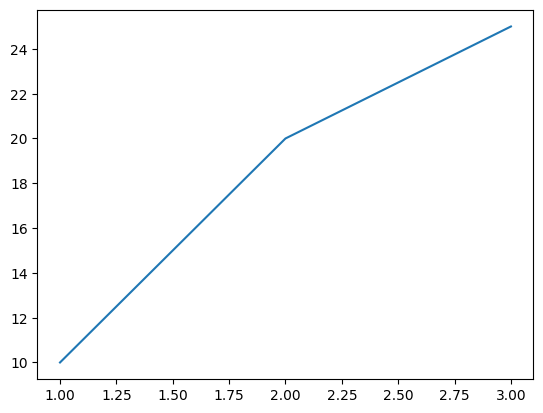

In [6]:
fig, ax = plt.subplots() # in this code we have (1 figure adn 1 axes)
ax.plot([1, 2, 3], [10, 20, 25])
plt.show()


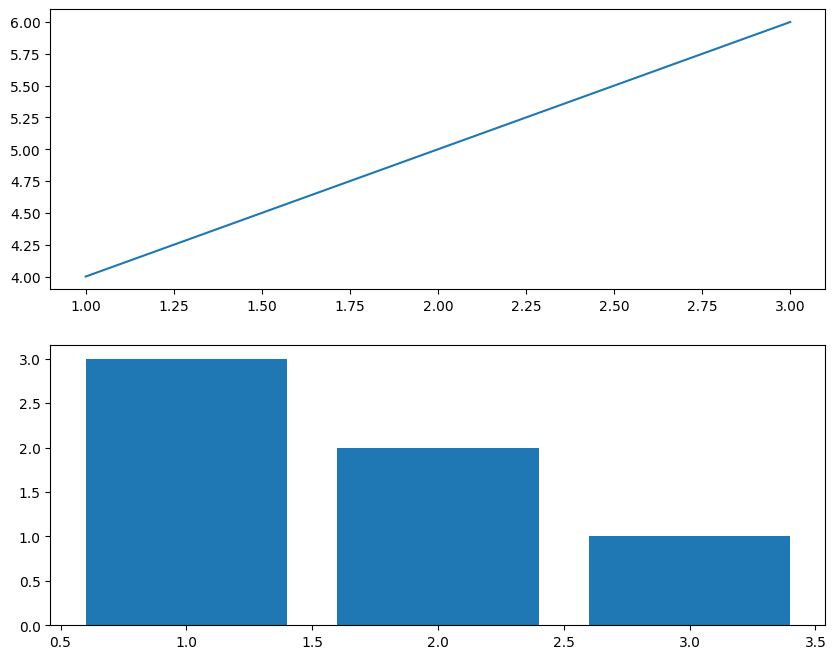

In [ ]:
fig , axs = plt.subplots(2,figsize = (10,8)) # we have (1 figure and 2 axes)

axs[0].plot([1, 2, 3], [4, 5, 6])
axs[1].bar([1, 2, 3], [3, 2, 1])
plt.show()

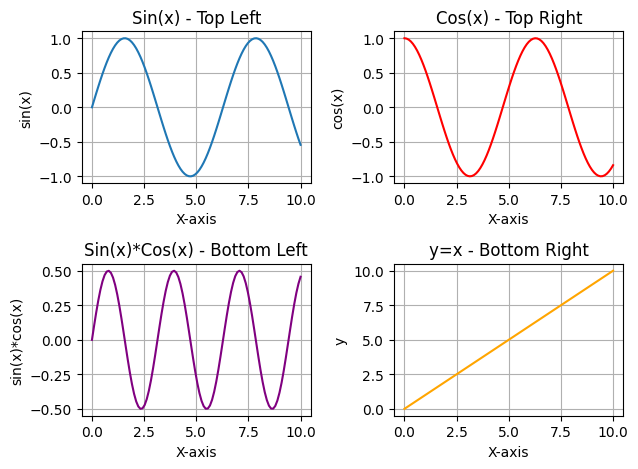

In [8]:
# 1. Create a Figure and a 2x2 grid of Axes
# plt.subplots(2, 2) creates a figure and a 2D array of Axes objects.
# 'fig' is the Figure object (the overall window or page).
# 'ax' is a 2D NumPy array containing the Axes objects for each subplot.
fig, ax = plt.subplots(nrows=2, ncols=2)

# Example data
x = np.linspace(0, 10, 100)
y_sin = np.sin(x)
y_cos = np.cos(x)

# 2. Plotting on the Axes objects
# Access individual Axes objects using array indexing (e.g., ax[row, column])

# Plotting on the top-left Axes (row 0, column 0)
ax[0, 0].plot(x, y_sin)
ax[0, 0].set_title('Sin(x) - Top Left')
ax[0, 0].set_xlabel('X-axis')
ax[0, 0].set_ylabel('sin(x)')
ax[0, 0].grid(True)

# Plotting on the top-right Axes (row 0, column 1)
ax[0, 1].plot(x, y_cos, color='red')
ax[0, 1].set_title('Cos(x) - Top Right')
ax[0, 1].set_xlabel('X-axis')
ax[0, 1].set_ylabel('cos(x)')
ax[0, 1].grid(True)

# Plotting on the bottom-left Axes (row 1, column 0)
ax[1, 0].plot(x, y_sin * y_cos, color='purple')
ax[1, 0].set_title('Sin(x)*Cos(x) - Bottom Left')
ax[1, 0].set_xlabel('X-axis')
ax[1, 0].set_ylabel('sin(x)*cos(x)')
ax[1, 0].grid(True)

# Plotting on the bottom-right Axes (row 1, column 1)
ax[1, 1].plot(x, x, color='orange')
ax[1, 1].set_title('y=x - Bottom Right')
ax[1, 1].set_xlabel('X-axis')
ax[1, 1].set_ylabel('y')
ax[1, 1].grid(True)

# 3. Adjust layout to prevent overlapping titles/labels
# plt.tight_layout() automatically adjusts subplot params so that the subplot(s) fits into the figure area.
plt.tight_layout()

# 4. Display the figure with all subplots
plt.show()


<p>
  ✨ 3. What are plt.gca() ?<br>

  <strong>plt.gca()</strong>: Get Current Axes<br>
  This function returns the current Axes object. It's useful for accessing and modifying the plot that is currently active, especially when you're not explicitly managing figure and axes objects.
</p>



<p dir="rtl"   style="text-align: center;">
<code dir="ltr"> plt.gca()</code>
</p>

In [ ]:
plt.figure(figsize=(6, 4))
ax = plt.gca()  # get current axis
ax.plot([1, 2, 3], [3, 6, 9])
ax.set_title("both")
plt.show()

<p dir="rtl"   style="text-align: center;">
<code dir="ltr">plt.savefig()</code>
</p>

<table dir="ltr" border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Format</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code dir="ltr">.png</code></td>
      <td>High-quality raster image (most common)</td>
    </tr>
    <tr>
      <td><code dir="ltr">.jpg</code> / <code dir="ltr">.jpeg</code></td>
      <td>Compressed, suitable for web</td>
    </tr>
    <tr>
      <td><code dir="ltr">.pdf</code></td>
      <td>Vector format for print</td>
    </tr>
    <tr>
      <td><code dir="ltr">.svg</code></td>
      <td>Vector format (web and Illustrator friendly)</td>
    </tr>
    <tr>
      <td><code dir="ltr">.eps</code></td>
      <td>Vector format (for LaTeX and professional printing)</td>
    </tr>
    <tr>
      <td><code dir="ltr">.tiff</code></td>
      <td>Very high quality (e.g., for scientific journal printing)</td>
    </tr>
  </tbody>
</table>


<table dir="ltr" border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Parameter</th>
      <th>Description</th>
      <th>Example</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code dir="ltr">fname</code></td>
      <td>File name and path</td>
      <td><code dir="ltr">"plots/my_chart.png"</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">dpi</code></td>
      <td>Image resolution (dots per inch)</td>
      <td><code dir="ltr">plt.savefig("img.png", dpi=300)</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">bbox_inches</code></td>
      <td>Specifies the portion of the figure to save</td>
      <td><code dir="ltr">"tight"</code> to trim excess whitespace</td>
    </tr>
    <tr>
      <td><code dir="ltr">facecolor</code></td>
      <td>Background color</td>
      <td><code dir="ltr">plt.savefig("img.png", facecolor="white")</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">transparent</code></td>
      <td>Background transparency (True/False)</td>
      <td><code dir="ltr">plt.savefig("img.png", transparent=True)</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">pad_inches</code></td>
      <td>Padding around the plot</td>
      <td><code dir="ltr">plt.savefig("img.png", bbox_inches="tight", pad_inches=0.2)</code></td>
    </tr>
  </tbody>
</table>


<p dir="ltr">
🧠 Important Notes<br><br>
Order is important!<br>
Always write <code dir="ltr">plt.savefig()</code> before <code dir="ltr">plt.show()</code>.<br>
Because in some environments (like IDLE or some IDEs), <code dir="ltr">plt.show()</code> might close the Figure, and you won't be able to save it afterward.<br><br>
In the object-oriented approach, you can also use the Figure's <code dir="ltr">savefig()</code> method:<br><br>
<code dir="ltr">fig, ax = plt.subplots()</code><br>
<code dir="ltr">ax.plot([1, 2, 3], [1, 4, 9])</code><br>
<code dir="ltr">fig.savefig("object_oriented.png", dpi=200)</code>
</p>


In [ ]:
# Sample data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create a figure and an axes.
fig, ax = plt.subplots(figsize=(8, 6)) # Adjust figure size as needed

# Plot the data
ax.plot(x, y, label='sin(x)')
ax.set_title('Basic Sine Wave Plot')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
ax.grid(True)

# Save the figure with a specific DPI and tight bounding box
# dpi=300 provides good resolution for most purposes.
# bbox_inches='tight' removes excess whitespace around the plot.
plt.savefig('sine_wave_basic.png', dpi=300, bbox_inches='tight')

# plt.show() # Usually commented out when saving, but useful for display
print("Saved 'sine_wave_basic.png'")


In [ ]:
# Sample data
x = np.linspace(0, 5, 50)
y = x**2

# Create a figure and an axes.
fig, ax = plt.subplots(figsize=(7, 5)) # Smaller figure for this example

# Plot the data
ax.plot(x, y, label='x^2', color='red')
ax.set_title('Quadratic Function Plot')
ax.set_xlabel('Input')
ax.set_ylabel('Output')
ax.legend()

# Save the figure as a PDF
# format='pdf' explicitly sets the format.
# transparent=True makes the background transparent.
# pad_inches=0.5 adds 0.5 inches of padding around the figure when using bbox_inches='tight'.
plt.savefig('quadratic_function.pdf', format='pdf', dpi=150, bbox_inches='tight', pad_inches=0.5, transparent=True)

# plt.show()
print("Saved 'quadratic_function.pdf' with transparency and padding.")


In [ ]:
# Sample data
x = np.arange(5)
y = [4, 7, 1, 9, 3]

# Create a figure and an axes using object-oriented approach
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the data
ax.plot(x, y, marker='o', linestyle='--', color='purple')
ax.set_title('Pointed Line Plot (OO Style)')
ax.set_xlabel('Index')
ax.set_ylabel('Value')
ax.grid(True)

# Save the figure using the figure object's savefig method
# This is functionally equivalent to plt.savefig() when you have a single active figure.
# Using a JPEG format this time.
fig.savefig('pointed_line_oo.jpg', dpi=250, bbox_inches='tight', format='jpg')

# plt.show()
print("Saved 'pointed_line_oo.jpg' using fig.savefig().")


<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.legend()</code>
</p>

<table dir="ltr" border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Parameter</th>
      <th>Description</th>
      <th>Example</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code dir="ltr">loc</code></td>
      <td>Location to display the legend</td>
      <td><code dir="ltr">plt.legend(loc='upper left')</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">bbox_to_anchor</code></td>
      <td>More precise positioning (in conjunction with loc)</td>
      <td><code dir="ltr">plt.legend(loc='upper right', bbox_to_anchor=(1,1))</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">title</code></td>
      <td>Title above the legend</td>
      <td><code dir="ltr">plt.legend(title='Data Groups')</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">fontsize</code></td>
      <td>Font size</td>
      <td><code dir="ltr">plt.legend(fontsize=12)</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">ncol</code></td>
      <td>Number of columns</td>
      <td><code dir="ltr">plt.legend(ncol=2)</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">frameon</code></td>
      <td>Display/hide the frame around the legend</td>
      <td><code dir="ltr">plt.legend(frameon=False)</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">facecolor</code></td>
      <td>Background color of the frame</td>
      <td><code dir="ltr">plt.legend(facecolor='lightgray')</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">edgecolor</code></td>
      <td>Color of the frame's border</td>
      <td><code dir="ltr">plt.legend(edgecolor='black')</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">shadow</code></td>
      <td>Add a shadow to the frame</td>
      <td><code dir="ltr">plt.legend(shadow=True)</code></td>
    </tr>
    <tr>
      <td><code dir="ltr">framealpha</code></td>
      <td>Transparency of the frame (0 to 1)</td>
      <td><code dir="ltr">plt.legend(framealpha=0.5)</code></td>
    </tr>
  </tbody>
</table>


<table dir="ltr" border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Value</th>
      <th>Position</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code dir="ltr">'best'</code></td>
      <td>(Default) Automatically chooses the best non-overlapping position</td>
    </tr>
    <tr>
      <td><code dir="ltr">'upper right'</code></td>
      <td>Top right</td>
    </tr>
    <tr>
      <td><code dir="ltr">'upper left'</code></td>
      <td>Top left</td>
    </tr>
    <tr>
      <td><code dir="ltr">'lower left'</code></td>
      <td>Bottom left</td>
    </tr>
    <tr>
      <td><code dir="ltr">'lower right'</code></td>
      <td>Bottom right</td>
    </tr>
    <tr>
      <td><code dir="ltr">'center'</code></td>
      <td>Center of the figure</td>
    </tr>
    <tr>
      <td><code dir="ltr">'center left'</code></td>
      <td>Center left</td>
    </tr>
    <tr>
      <td><code dir="ltr">'center right'</code></td>
      <td>Center right</td>
    </tr>
    <tr>
      <td><code dir="ltr">'upper center'</code></td>
      <td>Top center</td>
    </tr>
    <tr>
      <td><code dir="ltr">'lower center'</code></td>
      <td>Bottom center</td>
    </tr>
  </tbody>
</table>


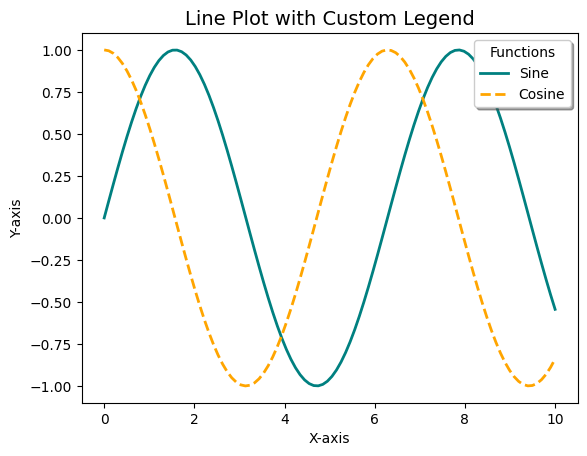

In [ ]:
# sample data
x = np.linspace(0, 10, 100)

plt.plot(x, np.sin(x), label='Sine', color='teal', linewidth=2)
plt.plot(x, np.cos(x), label='Cosine', color='orange', linestyle='--', linewidth=2)

plt.title("Line Plot with Custom Legend", fontsize=14)
plt.legend(loc='upper right', fontsize=10, frameon=True, shadow=True, title="Functions")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

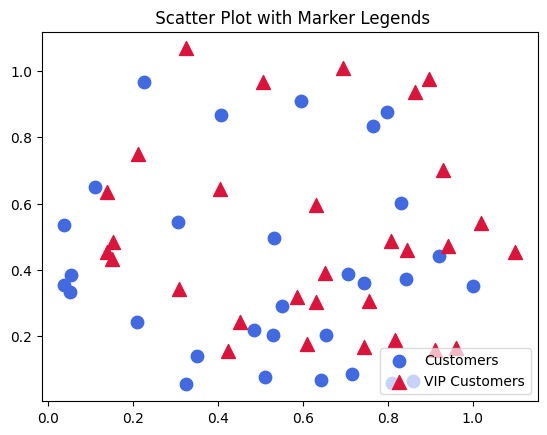

In [ ]:
# sample data
x = np.random.rand(30)
y = np.random.rand(30)

plt.scatter(x, y, color='royalblue', label='Customers', s=80, marker='o')
plt.scatter(x+0.1, y+0.1, color='crimson', label='VIP Customers', s=100, marker='^')

plt.title(" Scatter Plot with Marker Legends")
plt.legend(loc='lower right', fontsize=10, fancybox=True, framealpha=0.7)
plt.show()


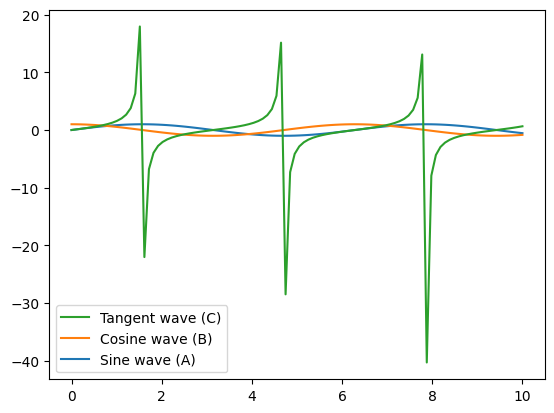

In [14]:
# sample data
x = np.linspace(0, 10, 100)

# Calculate corresponding y values for sine, cosine, and tangent functions
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.tan(x)

# Plot the sine wave with label "A"
lines = plt.plot(x, y1, label="Sine wave (A)")
# Plot the cosine wave with label "B"
plt.plot(x, y2, label="Cosine wave (B)")
# Plot the tangent wave with label "C"
plt.plot(x, y3, label="Tangent wave (C)")

# Retrieve the handles and labels for the legend
handles, labels = plt.gca().get_legend_handles_labels()

# Display the legend with reversed order of handles and labels
# This ensures that the last plotted item appears first in the legend
plt.legend(handles[::-1], labels[::-1])

# Display the plot
plt.show()


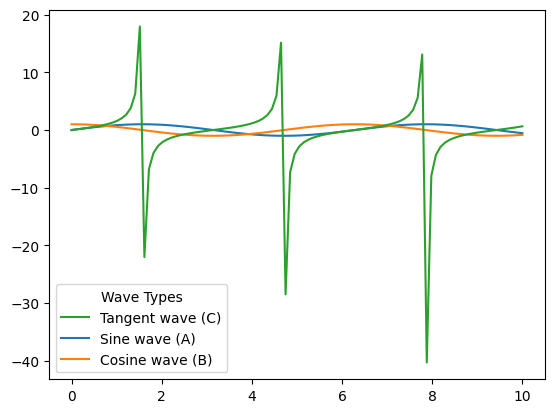

In [15]:
# sample data
# x = np.linspace(0, 10, 100)
# y1 = np.sin(x)
# y2 = np.cos(x)
# y3 = np.tan(x)
# -------------------------------------------------------------------

# Create a figure and a set of subplots (in this case, just one subplot)
fig, ax = plt.subplots()

# Plot the data series with labels
# ax.plot returns a list of Line2D objects; we capture them but don't strictly need them here
ax.plot(x, y1, label="Sine wave (A)")
ax.plot(x, y2, label="Cosine wave (B)")
ax.plot(x, y3, label="Tangent wave (C)")

# Retrieve the handles and labels for the legend from the axes object
handles, labels = ax.get_legend_handles_labels()

# Define a custom order for the legend items.
# The current order is [A, B, C] based on plotting order.
# We want to display them in the order: C, A, B.
# The indices correspond to the original order: A=0, B=1, C=2.
# So, the desired order is [index of C, index of A, index of B] -> [2, 0, 1].
custom_order_indices = [2, 0, 1]

# Create the legend with the specified custom order
# We use list comprehensions to select handles and labels according to custom_order_indices
ax.legend([handles[i] for i in custom_order_indices],
          [labels[i] for i in custom_order_indices],
          title="Wave Types") # Added a descriptive title for the legend

# Display the plot with the custom-ordered legend
plt.show()


<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.grid()</code>
</p>

<p>
Grid means the horizontal and vertical lines in the background of a chart that are aligned with the X and Y axes.<br><br>
📘 Its purpose:<br><br>
Helps with numerical readability<br>
Makes it easier to compare points<br>
Adds visual appeal (in certain styles)
</p>


In [ ]:
plt.grid(
    True,               # Show the grid
    which='major',      # Grid type: 'major', 'minor', or 'both'
    axis='both',        # Apply grid to both X and Y axes
    color='gray',       # Grid line color
    linestyle='--',     # Line style (e.g., '-', '--', ':', '-.')
    linewidth=0.8,      # Line thickness
    alpha=0.7           # Line transparency
)

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Value</th>
      <th>Meaning</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code dir="ltr">'major'</code></td>
      <td>Major tick lines</td>
      <td>Default option — standard grid lines on main ticks</td>
    </tr>
    <tr>
      <td><code dir="ltr">'minor'</code></td>
      <td>Minor tick lines</td>
      <td>Shows finer grid lines between the major ticks</td>
    </tr>
    <tr>
      <td><code dir="ltr">'both'</code></td>
      <td>Both major and minor lines</td>
      <td>Displays a full combination of both grid types</td>
    </tr>
  </tbody>
</table>


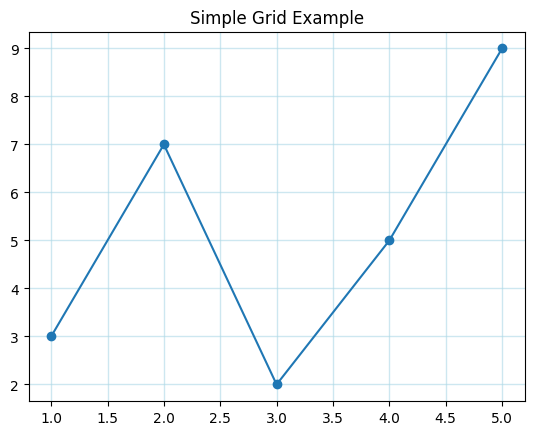

In [18]:
# sample data
x = [1, 2, 3, 4, 5]
y = [3, 7, 2, 5, 9]

plt.plot(x, y, marker='o')

# Enable grid with custom color and transparency
plt.grid(True, color='lightblue', linestyle='-', linewidth=1, alpha=0.6)

plt.title("Simple Grid Example")
plt.show()


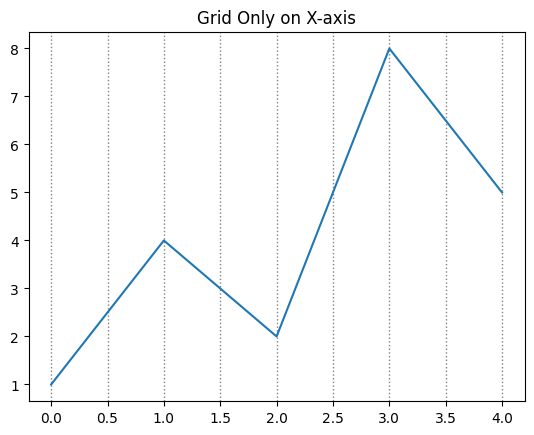

In [ ]:
# sample data
x = [0, 1, 2, 3, 4]
y = [1, 4, 2, 8, 5]

plt.plot(x, y)

# Show grid only on the X-axis
plt.grid(True, axis='x', linestyle=':', color='gray', linewidth=1)

plt.title("Grid Only on X-axis")
plt.show()


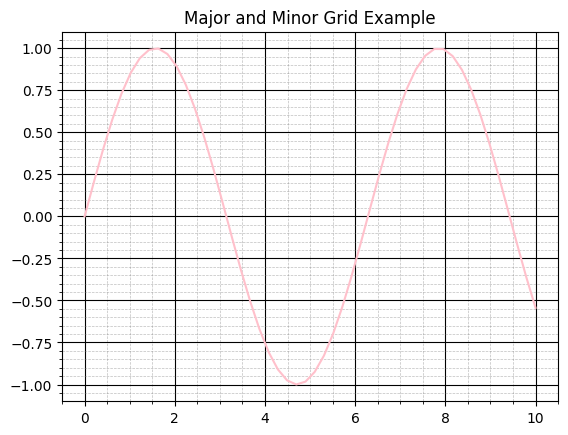

In [27]:
# sample data

x = np.linspace(0, 10, 50)
y = np.sin(x)

plt.plot(x, y , color = 'pink')

# Turn on minor ticks
plt.minorticks_on()

# Major grid
plt.grid(True, which='major', color='black', linestyle='-', linewidth=0.8) 

# Minor grid
plt.grid(True, which='minor', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

plt.title("Major and Minor Grid Example")
plt.show()


<p dir="rtl"  style="text-align: center;">
<code dir="ltr">ax.spines</code>
</p>

<p>
The <strong>ax.spines</strong> property in Matplotlib is one of its most powerful and interesting features.<br><br>
It allows you to control the border lines around the chart (the frame of the plot).<br><br>
By default, a chart has <strong>4 spines</strong>:<br><br>
🔹 <strong>top</strong> → the line at the top of the plot<br>
🔹 <strong>bottom</strong> → the line at the bottom<br>
🔹 <strong>left</strong> → the line on the left side<br>
🔹 <strong>right</strong> → the line on the right side
</p>


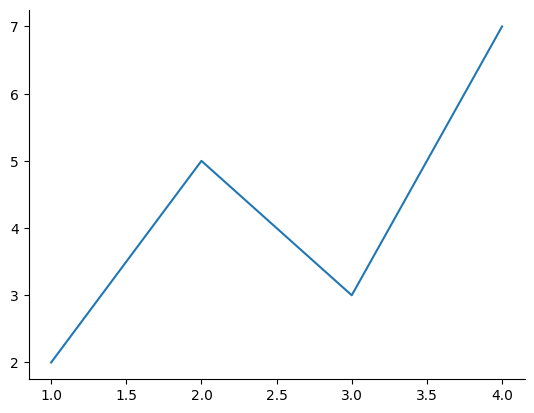

In [39]:
# sample data
x = [1, 2, 3, 4]
y = [2, 5, 3, 7]

fig, ax = plt.subplots()

ax.plot(x, y)

# Hide the top and right borders of the plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


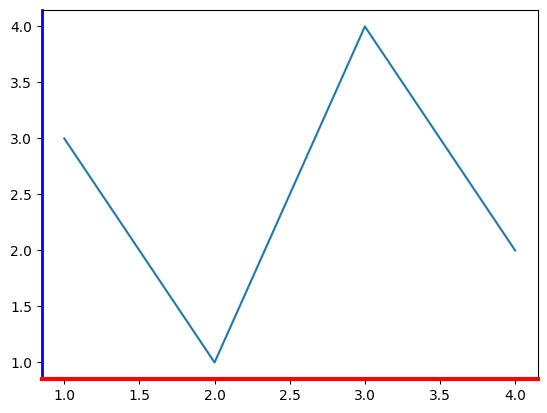

In [40]:
# sample data
x = [1, 2, 3, 4]
y = [3, 1, 4, 2]

fig, ax = plt.subplots()

ax.plot(x, y)

# Change spine color and thickness
ax.spines['bottom'].set_color('red')
ax.spines['bottom'].set_linewidth(3)

ax.spines['left'].set_color('blue')
ax.spines['left'].set_linewidth(2)

plt.show()


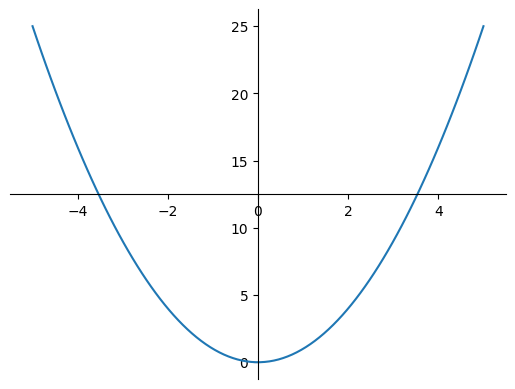

In [33]:
# sample data
x = np.linspace(-5, 5, 100)
y = x**2

fig, ax = plt.subplots()

ax.plot(x, y)

# Move left spine to the center (x = 0)
ax.spines['left'].set_position('center')

# Move bottom spine to the center (y = 0)
ax.spines['bottom'].set_position('center')

# Hide the unnecessary spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()


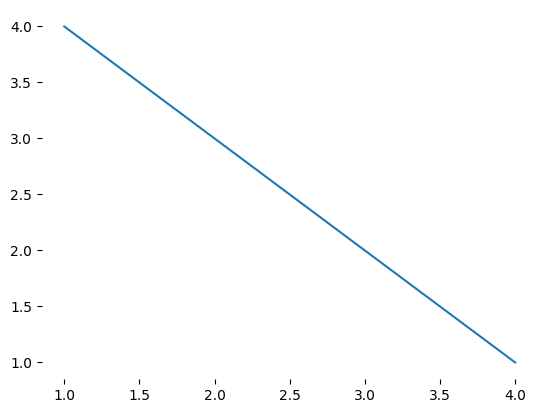

In [41]:
# sample data
x = [1,2,3,4]
y = [4,3,2,1]

fig, ax = plt.subplots()

ax.plot(x, y)

# Hide all spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()


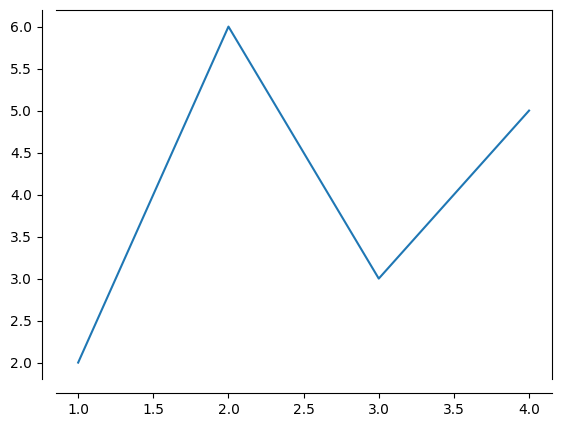

In [43]:
# sample data
x = [1,2,3,4]
y = [2,6,3,5]

fig, ax = plt.subplots()

ax.plot(x, y)

# Move bottom spine outward by 10 points
ax.spines['bottom'].set_position(('outward', 10))

# Move left spine outward by 10 points
ax.spines['left'].set_position(('outward', 10))

plt.show()


<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.xlim() , plt.ylim()</code>
</p>

<p>
The functions <strong>plt.xlim(min, max)</strong> and <strong>plt.ylim(min, max)</strong> in Matplotlib are used to set the range of the X and Y axes.<br><br>
🔹 For <strong>plt.xlim(min, max)</strong>:<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>min</strong> → the minimum value of the X axis<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>max</strong> → the maximum value of the X axis<br><br>
🔹 For <strong>plt.ylim(min, max)</strong>:<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>min</strong> → the minimum value of the Y axis<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>max</strong> → the maximum value of the Y axis
</p>


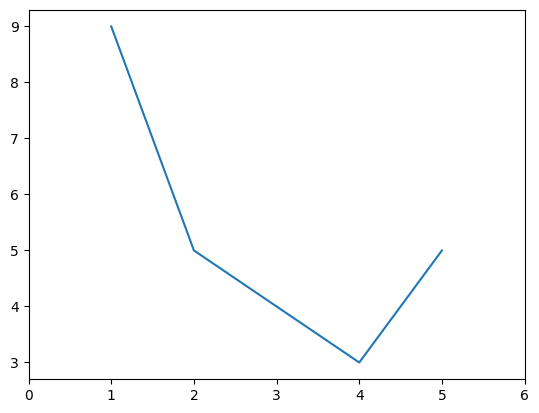

In [46]:
# sample data
x = [1, 2, 3, 4, 5]
y = [9, 5, 4, 3, 5]

plt.plot(x, y)

# Set the range of the X-axis from 0 to 6
plt.xlim(0, 6)

plt.show()

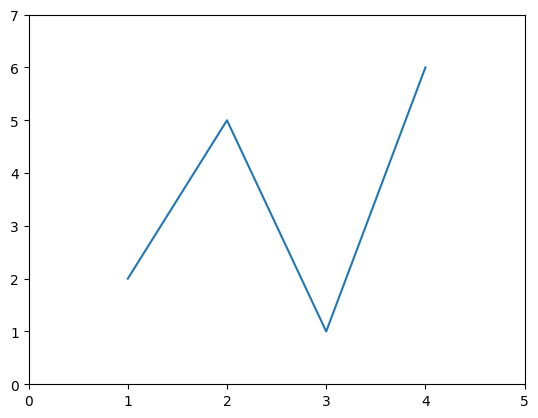

In [45]:
# sample data
x = [1, 2, 3, 4]
y = [2, 5, 1, 6]

plt.plot(x, y)

# Set X-axis limits
plt.xlim(0, 5)

# Set Y-axis limits
plt.ylim(0, 7)

plt.show()

In [ ]:
# Get current x-axis limits
print(plt.xlim())

# Get current y-axis limits
print(plt.ylim())

In [ ]:
# sample data
x = [1,2,3,4]
y = [2,6,3,5]

fig, ax = plt.subplots()

ax.plot(x, y)

# Set axis limits using the Axes object 
ax.set_xlim(0, 5)
ax.set_ylim(0, 7)

plt.show()

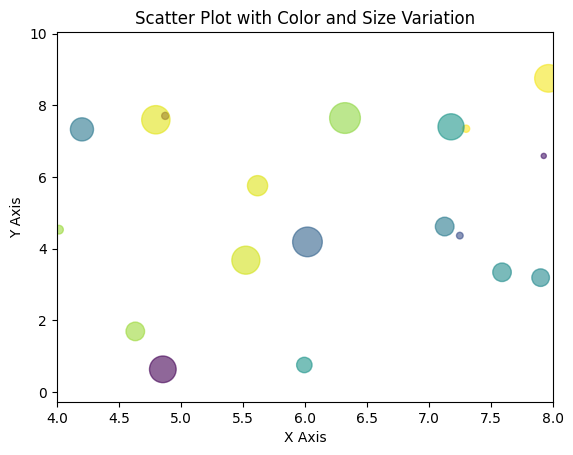

In [55]:
# sample data
np.random.seed(11)
x = np.random.rand(50) * 10  
y = np.random.rand(50) * 10   
colors = np.random.rand(50) 
sizes = 500 * np.random.rand(50)  

# Create a scatter plot.
# x and y define the positions of the points.
# s=sizes sets the size of each point.
# c=colors sets the color of each point, using a colormap.
# alpha=0.6 sets the transparency of the points (0=fully transparent, 1=fully opaque).
plt.scatter(x,y,s=sizes ,c = colors , alpha = 0.6)

plt.title("Scatter Plot with Color and Size Variation")

plt.xlabel("X Axis")
plt.ylabel("Y Axis")

# Set the limits for the X-axis to be between 4 and 5 (to zoom in on a specific section of the chart along the X-axis)
plt.xlim(4,8)

# Display the plot.
plt.show()


<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.xticks() , plt.yticks()</code>
</p>

<p>
The function <strong>plt.xticks()</strong> in Matplotlib is used to customize the tick marks on the X axis.<br><br>
🔹 You can use it to <strong>set the positions</strong> and optionally the <strong>labels</strong> of the tick marks.<br><br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>plt.xticks(ticks)</strong> → sets the tick positions along the X axis<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>plt.xticks(ticks, labels)</strong> → sets both the positions and custom text labels for each tick<br><br>
✅ This function is especially useful for making your chart easier to read or for replacing numerical ticks with descriptive category names.<br>

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Parameter</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>rotation</code></td>
      <td>The angle of rotation for tick labels (e.g., 45 or 90 degrees)</td>
    </tr>
    <tr>
      <td><code>fontsize</code></td>
      <td>The size of the font</td>
    </tr>
    <tr>
      <td><code>color</code></td>
      <td>The color of the text</td>
    </tr>
    <tr>
      <td><code>fontweight</code></td>
      <td>The weight or thickness of the font (‘bold’, ‘light’, ...)</td>
    </tr>
    <tr>
      <td><code>ha</code></td>
      <td>Horizontal alignment (‘left’, ‘center’, ‘right’)</td>
    </tr>
  </tbody>
</table>


<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Function</th>
      <th>Command</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Set tick positions</td>
      <td><code>plt.yticks([0, 5, 10])</code></td>
    </tr>
    <tr>
      <td>Set tick labels</td>
      <td><code>plt.yticks([0, 5, 10], ['A', 'B', 'C'])</code></td>
    </tr>
    <tr>
      <td>Change size/color</td>
      <td><code>plt.yticks(fontsize=12, color='red')</code></td>
    </tr>
    <tr>
      <td>Get current values</td>
      <td><code>plt.yticks()</code></td>
    </tr>
    <tr>
      <td>Object-oriented equivalent</td>
      <td><code>ax.set_yticks()</code> and <code>ax.set_yticklabels()</code></td>
    </tr>
  </tbody>
</table>


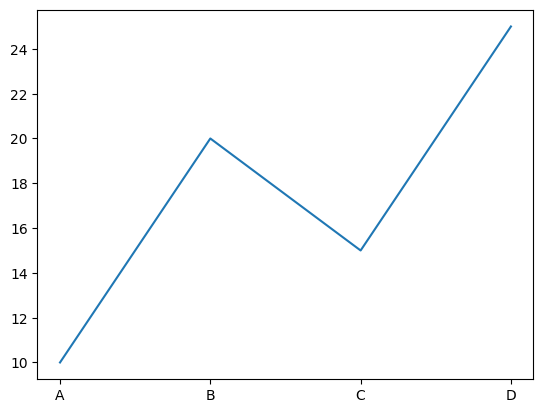

In [ ]:
# sample data
x = [1,2,3,4]
y = [10,20,15,25]

plt.plot(x, y)

# Custom labels for X-axis ticks
plt.xticks([1,2,3,4], ['A', 'B', 'C', 'D'])

plt.show()

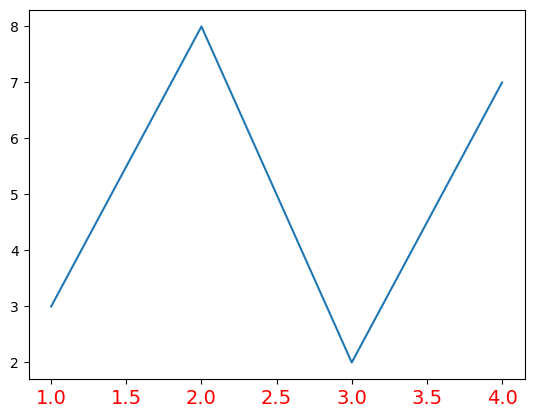

In [59]:
# sample data
x = [1,2,3,4]
y = [3,8,2,7]

plt.plot(x, y)

# Change tick label size and color
plt.xticks(fontsize=14, color='red')

plt.show()

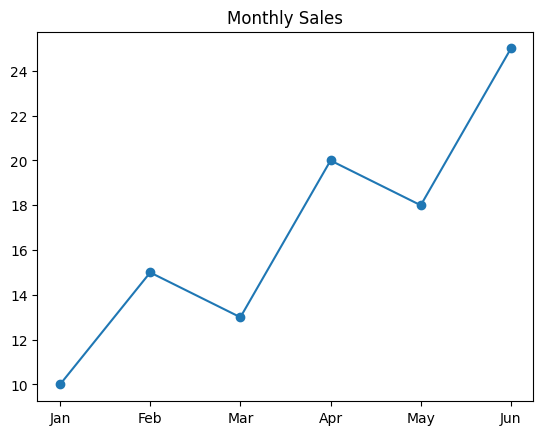

In [60]:
# sample name
months = [1,2,3,4,5,6]
sales = [10,15,13,20,18,25]

plt.plot(months, sales, marker='o')

# Replace numbers with month names
plt.xticks(
    [1,2,3,4,5,6],
    ['Jan','Feb','Mar','Apr','May','Jun']
)

plt.title("Monthly Sales")

plt.show()

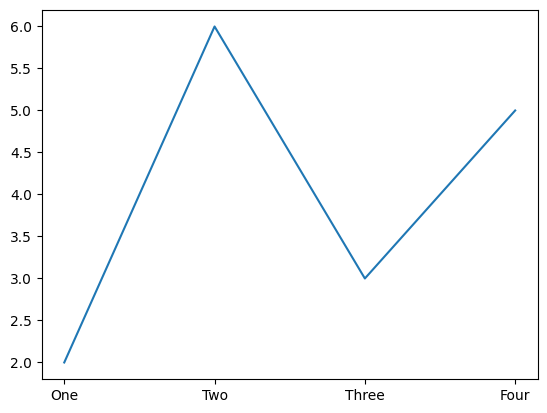

In [ ]:
# sample data
x = [1,2,3,4]
y = [2,6,3,5]

fig, ax = plt.subplots()

ax.plot(x, y)

# Set custom tick positions
ax.set_xticks([1,2,3,4])

# Set custom tick labels
ax.set_xticklabels(['One','Two','Three','Four'])

plt.show()

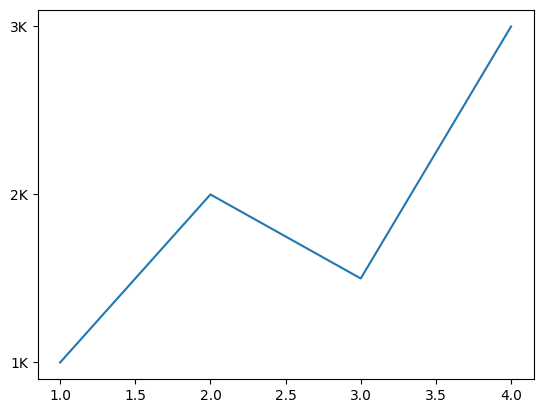

In [62]:
# sample dataa
x = [1,2,3,4]
y = [1000, 2000, 1500, 3000]

plt.plot(x, y)

# Replace numeric values with readable labels
plt.yticks(
    [1000, 2000, 3000],
    ['1K', '2K', '3K']
)

plt.show()


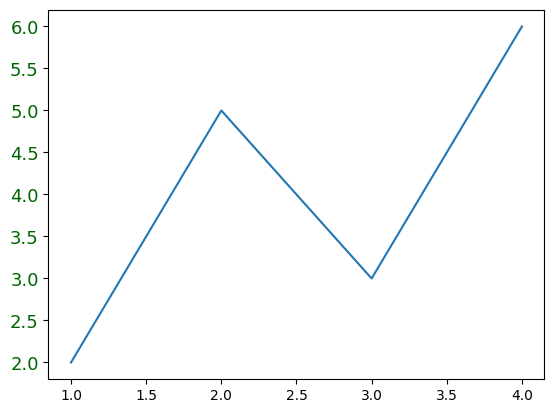

In [63]:
# sample data
x = [1,2,3,4]
y = [2,5,3,6]

plt.plot(x, y)

# Customize Y-axis tick label appearance
plt.yticks(fontsize=13, color='darkgreen')

plt.show()


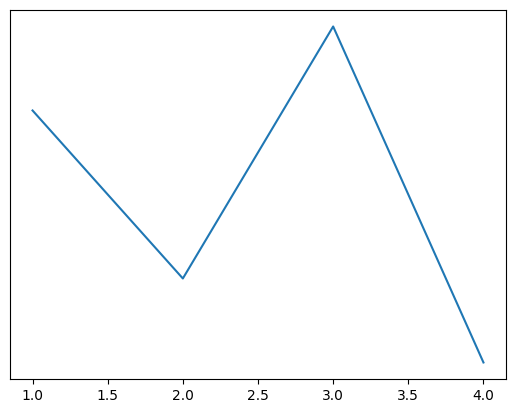

In [64]:
# sample data
x = [1,2,3,4]
y = [5,3,6,2]

plt.plot(x, y)

# Remove all Y-axis ticks
plt.yticks([])

plt.show()

<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.tight_layout()</code>
</p>

<p>
The function <strong>plt.tight_layout()</strong> in Matplotlib automatically adjusts the spacing between subplots so that labels, titles, and tick marks fit nicely within the figure area.<br>
🔹 It helps prevent overlapping text and ensures the plot looks clean and readable.<br>
✅ Common usage: simply call <strong>plt.tight_layout()</strong> after creating all subplots.<br><br>

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Parameter</th>
      <th>Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><code>pad</code></td>
      <td>The overall padding between subplots and the figure edge (in font-size units) — default is <code>1.08</code></td>
    </tr>
    <tr>
      <td><code>w_pad</code></td>
      <td>Horizontal spacing between subplots</td>
    </tr>
    <tr>
      <td><code>h_pad</code></td>
      <td>Vertical spacing between subplots</td>
    </tr>
    <tr>
      <td><code>rect</code></td>
      <td>The portion of the figure area used to adjust the layout (e.g., <code>[left, bottom, right, top]</code>)</td>
    </tr>
  </tbody>
</table>


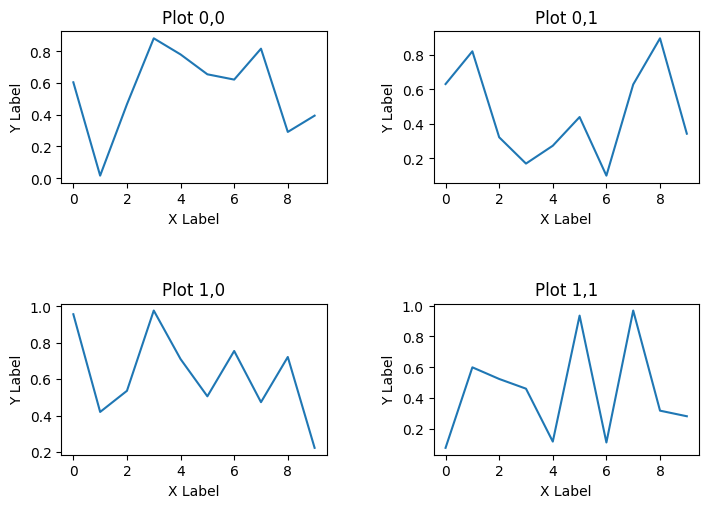

In [74]:
fig, axs = plt.subplots(2, 2, figsize=(8,6))

for i in range(2):
    for j in range(2):
        axs[i, j].plot(np.random.rand(10))
        axs[i, j].set_title(f"Plot {i},{j}")
        axs[i, j].set_xlabel("X Label")
        axs[i, j].set_ylabel("Y Label")

# Automatically adjust spacing
plt.tight_layout(pad=4)

plt.show()


<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.tick_params()</code>
</p>

<p>
The function <strong>plt.tick_params()</strong> in Matplotlib is used to customize the appearance, position, and style of tick marks and tick labels on both the X and Y axes.<br><br>

🔹 With <strong>plt.tick_params()</strong>:<br>
&nbsp;&nbsp;&nbsp;&nbsp;• You control the **visual style** (appearance) of ticks — their length, direction, width, color, and label size.<br>
&nbsp;&nbsp;&nbsp;&nbsp;• It does **not change** the tick positions or values — only how they look.<br><br>


🔸 **Difference from <code>plt.xticks()</code> and <code>plt.yticks()</code>:**<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>plt.xticks()</strong> / <strong>plt.yticks()</strong> → control **the position and labels** of ticks (what values to show and what text to display).<br>
&nbsp;&nbsp;&nbsp;&nbsp;• <strong>plt.tick_params()</strong> → controls **the style and appearance** of ticks and labels (how they look, not what they show).<br><br>

In short:<br>
&nbsp;&nbsp;&nbsp;&nbsp;<code>xticks()</code> / <code>yticks()</code> → *content* of ticks ✅<br>
&nbsp;&nbsp;&nbsp;&nbsp;<code>tick_params()</code> → *style* of ticks 🎨
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.axhline()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.axvline()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.axvspan()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.axhspan()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.text()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.annotate()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr"> plt.fill_between()</code>
</p>

<p dir="rtl"  style="text-align: center;">
<code dir="ltr">plt.gca().invert_yaxis()</code>
</p>